In [12]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'fear_greed_index.csv', 'historical_data.csv', 'trader_analysis.ipynb']


In [18]:
import pandas as pd
fear = pd.read_csv("fear_greed_index.csv")
historical = pd.read_csv("historical_data.csv")

print(fear.head())
print(historical.head())


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [26]:
fear['date'] = pd.to_datetime(fear['date']).dt.date

In [25]:
historical['Timestamp IST'] = pd.to_datetime(
    historical['Timestamp IST'], dayfirst = True
)        
historical['date'] = historical['Timestamp IST'].dt.date

In [27]:
merged = pd.merge(historical, fear, on = 'date', how='left')
print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [28]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [29]:
daily_pnl = merged.groupby('date')['Closed PnL'].sum()
print(daily_pnl.head())

date
2023-05-01      0.000000
2023-12-05      0.000000
2023-12-14   -205.434737
2023-12-15    -24.632034
2023-12-16      0.000000
Name: Closed PnL, dtype: float64


In [30]:
win_rate = merged.groupby('date').apply(
    lambda x: (x['Closed PnL'] > 0).mean()
)
print(win_rate.head())
    

date
2023-05-01    0.000000
2023-12-05    0.000000
2023-12-14    0.363636
2023-12-15    0.000000
2023-12-16    0.000000
dtype: float64


In [31]:
trades_per_day = merged.groupby('date').size()
print(trades_per_day.head())

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64


In [32]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


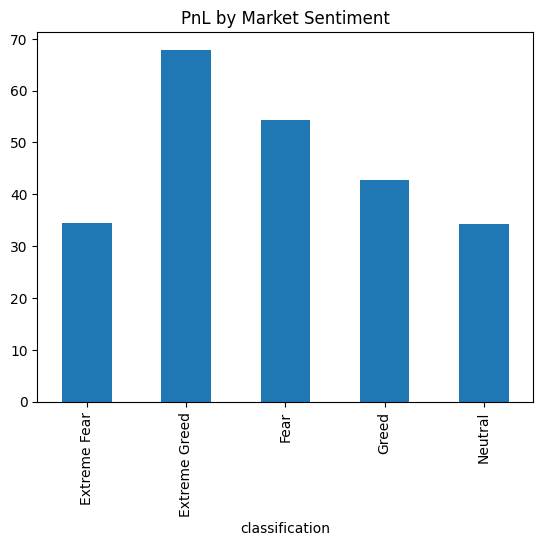

In [33]:
import matplotlib.pyplot as plt
pnl_sentiment.plot(kind = 'bar' , title = "PnL by Market Sentiment")
plt.show()

In [41]:
behaviour = merged.groupby('classification').agg({
    'Size USD' : 'mean',
 'Closed PnL': 'count'
})
print(behaviour)

                   Size USD  Closed PnL
classification                         
Extreme Fear    5349.731843       21400
Extreme Greed   3112.251565       39992
Fear            7816.109931       61837
Greed           5736.884375       50303
Neutral         4782.732661       37686
